<a href="https://colab.research.google.com/github/2400030303/AI-LEARNINGS-WITH-PYTHON-STARTERS/blob/main/EXPLORATORY_DATA_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df=pd.read_csv("products-100.csv")
print(df)

    Index                                   Name  \
0       1   Compact Printer Air Advanced Digital   
1       2                                 Tablet   
2       3                   Smart Blender Cooker   
3       4           Advanced Router Rechargeable   
4       5           Portable Mouse Monitor Phone   
..    ...                                    ...   
95     96                                 Router   
96     97     Fast Thermostat Microphone Scooter   
97     98  Eco Heater Toaster Stove Silent Sense   
98     99               Clean Blender Scale Lite   
99    100                             Smart Lamp   

                                          Description  \
0       Situation organization these memory much off.   
1         Discussion loss politics free one thousand.   
2                                   No situation per.   
3                     For force gas energy six laugh.   
4   Feeling back religious however author room sci...   
..                               

In [2]:
print (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Index         100 non-null    int64 
 1   Name          100 non-null    object
 2   Description   100 non-null    object
 3   Brand         100 non-null    object
 4   Category      100 non-null    object
 5   Price         100 non-null    int64 
 6   Currency      100 non-null    object
 7   Stock         100 non-null    int64 
 8   EAN           100 non-null    int64 
 9   Color         100 non-null    object
 10  Size          100 non-null    object
 11  Availability  100 non-null    object
 12  Internal ID   100 non-null    int64 
dtypes: int64(5), object(8)
memory usage: 10.3+ KB
None


Step 3 — Check missing values 🔎

Even though info() suggests there are no nulls, let's explicitly check them.

In [4]:
print(df.isnull().sum())

Index           0
Name            0
Description     0
Brand           0
Category        0
Price           0
Currency        0
Stock           0
EAN             0
Color           0
Size            0
Availability    0
Internal ID     0
dtype: int64


In [5]:
#Step 4 — Duplicates
print(df.duplicated().sum())

0


In [6]:
print(df.describe())

            Index      Price       Stock           EAN  Internal ID
count  100.000000  100.00000  100.000000  1.000000e+02   100.000000
mean    50.500000  451.19000  545.710000  4.876267e+12    49.340000
std     29.011492  281.60911  266.716863  2.918084e+12    28.078253
min      1.000000    1.00000   10.000000  5.246382e+08     3.000000
25%     25.750000  230.75000  347.500000  2.062323e+12    25.000000
50%     50.500000  407.50000  575.500000  4.875720e+12    48.000000
75%     75.250000  679.00000  749.250000  7.676943e+12    74.500000
max    100.000000  999.00000  998.000000  9.921752e+12    99.000000


In [8]:
q1=df["Price"].quantile(0.25)
q3=df["Price"].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
outliers=df[(df["Price"]<lower)|(df["Price"]>upper)]
print(outliers)

Empty DataFrame
Columns: [Index, Name, Description, Brand, Category, Price, Currency, Stock, EAN, Color, Size, Availability, Internal ID]
Index: []


In [9]:
#CATEGORY ANALYSIS
print(df["Category"].value_counts())

Category
Automotive                         6
Health & Wellness                  6
Cleaning Supplies                  6
Kids' Clothing                     5
Women's Clothing                   5
Office Supplies                    5
Books & Stationery                 4
Smartphones                        4
Fragrances                         4
Beauty & Personal Care             4
Bedding & Bath                     4
Kitchen Appliances                 3
Cycling                            3
Fitness Equipment                  3
Skincare                           3
Laptops & Computers                3
Camping & Hiking                   3
Sports & Outdoors                  3
Haircare                           3
Shoes & Footwear                   2
Grooming Tools                     2
Team Sports                        2
Home Decor                         2
Furniture                          2
Smartwatches                       2
Makeup                             2
Cameras & Accessories        

In [12]:
#AVAILABILITY
print(df["Availability"].value_counts())

Availability
pre_order        25
in_stock         20
limited_stock    17
backorder        16
discontinued     12
out_of_stock     10
Name: count, dtype: int64


In [14]:
print(df.groupby("Category")["Price"].mean())
#df.groupby("GROUP_COLUMN")["NUMERIC_COLUMN"].aggregation()
print(df.groupby("Category")["Price"].max())

Category
Accessories (Bags, Hats, Belts)    206.000000
Automotive                         421.666667
Beauty & Personal Care             278.500000
Bedding & Bath                     453.000000
Books & Stationery                 388.500000
Cameras & Accessories              444.500000
Camping & Hiking                   612.666667
Cleaning Supplies                  391.333333
Clothing & Apparel                 858.000000
Cycling                            799.333333
Fishing & Hunting                  100.000000
Fitness Equipment                  703.333333
Fragrances                         477.500000
Furniture                          689.000000
Grooming Tools                     702.500000
Haircare                           681.666667
Health & Wellness                  268.333333
Home & Kitchen                     367.500000
Home Decor                         782.500000
Kids' Clothing                     397.800000
Kitchen Appliances                 251.000000
Laptops & Computers      

/tmp/ipykernel_555/642845394.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


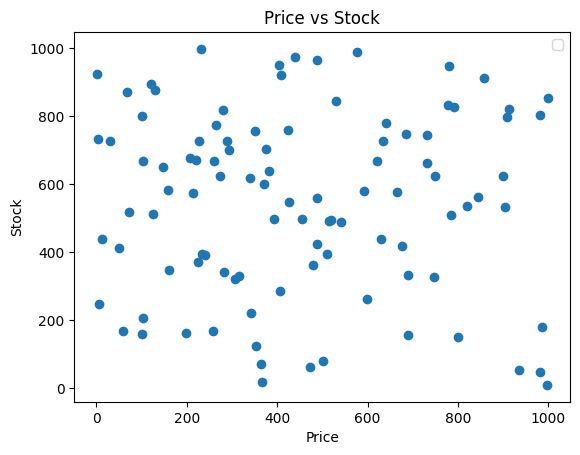

In [15]:
import matplotlib.pyplot as plt
plt.scatter(df["Price"],df["Stock"])
plt.xlabel("Price")
plt.ylabel("Stock")
plt.title("Price vs Stock")
plt.legend()
plt.show()

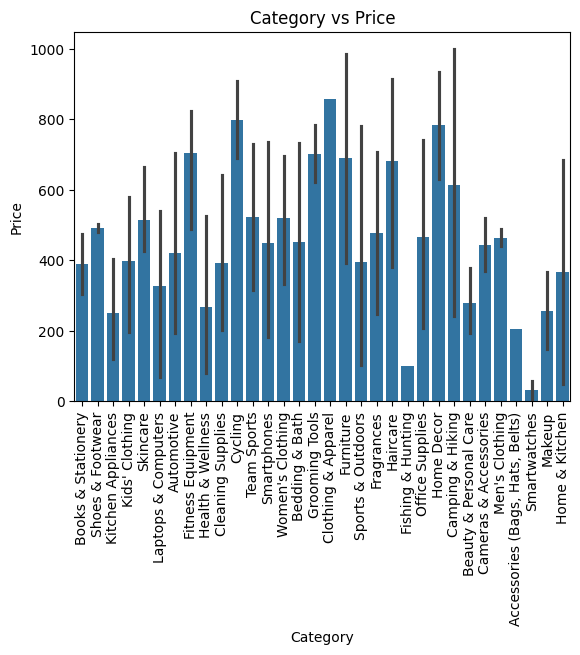

In [18]:
import seaborn as sns
sns.barplot(x="Category",y="Price",data=df)

plt.xlabel("Category")
plt.ylabel("Price")
plt.title("Category vs Price")

plt.xticks(rotation=90)

plt.show()